# 📚 Structures de données — NumPy / Listes / Strings / Tuples / Dict / Set / xarray

Notebook **cheat-sheet** (+ wiki léger) des structures de données du quotidien data en Python :
les *built-ins* (list, tuple, dict, set, str), le module `collections`, et les tableaux
scientifiques **NumPy** (N-D) et **xarray** (N-D labellisés).

Couverture :

1. **NumPy** — création, `reshape` (ordre C/F), `stack`, broadcasting, indexing avancé, ufuncs.
2. **Listes** — slicing, méthodes, recherche/tri, aplatissement, conversions, découpage en N.
3. **Chaînes (str)** — casse, nettoyage, alignement, recherche.
4. **Tuples** — unpacking, swap, `namedtuple`, `dataclass(frozen=True)`.
5. **Dictionnaires** — création, itération, merge, dict-de-dicts, subset, flatten.
6. **Sets** — opérations ensemblistes, `frozenset`.
7. **`collections`** — `Counter`, `defaultdict`, `deque`, `OrderedDict`, `ChainMap`.
8. **xarray** — tableaux N-D labellisés (sélection par label, `groupby`, NetCDF).

> Snippets autonomes, copiables tels quels. Code typé, exécuté de bout en bout (seed = 42).

## 1. NumPy — le tableau N-dimensionnel

`numpy.ndarray` est le bloc de base du calcul scientifique : un tableau **homogène**
(un seul `dtype`) et **contigu** en mémoire, qui vectorise les opérations (boucles C sous le capot).

Plusieurs fabriques de création selon le besoin (zéros, identité, plages, tirages aléatoires).
Le générateur moderne `np.random.default_rng(seed)` remplace l'ancien `np.random.seed` global.

In [ ]:
from __future__ import annotations

import itertools as it
from collections import (ChainMap, Counter, OrderedDict, defaultdict, deque,
                         namedtuple)
from dataclasses import dataclass
from typing import Any, Iterable, Iterator

import numpy as np

rng = np.random.default_rng(42)  # générateur moderne, reproductible (seed=42)

# Différentes créations d'arrays
np.zeros((3, 4))                  # zéros
np.ones((2, 3), dtype=np.float32) # uns, dtype imposé
np.eye(4)                         # identité
np.arange(10, 20, 2)              # [10,12,14,16,18] (start, stop, step)
np.linspace(0, 1, 5)              # 5 valeurs régulières sur [0,1]
print(rng.normal(0, 1, (2, 3)))   # tirage gaussien reproductible

Un `arange(1, 13)` produit le vecteur 1-D des entiers de 1 à 12 :

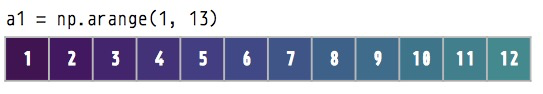

In [ ]:
a1 = np.arange(1, 13)  # entiers 1 à 12
print(a1)

`reshape` réinterprète les mêmes données sous une autre forme (sans copie si possible).
L'ordre **C** (*row-major*, défaut) remplit **ligne par ligne** : l'élément linéaire $k$ va en
position $(i, j)$ avec $i = k \,/\, n_{cols}$ et $j = k \bmod n_{cols}$.

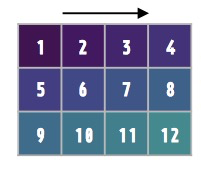

In [ ]:
a1_2dC = a1.reshape(3, 4)  # (3, 4) en row-major (défaut, order='C')
# Équivalents pratiques :
#   a1.reshape(-1, 4)        -> NumPy déduit le nb de lignes
#   a1.reshape(3, -1)        -> NumPy déduit le nb de colonnes
print("shape :", a1_2dC.shape)
print(a1_2dC)

L'ordre **F** (*column-major*, façon Fortran) remplit au contraire **colonne par colonne**.
Même buffer mémoire, lecture transposée :

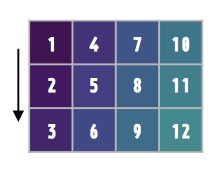

In [ ]:
a1_2dF = a1.reshape(3, 4, order="F")  # column-major (à la Fortran)
print("shape :", a1_2dF.shape)
print(a1_2dF)

`ravel` est l'opération inverse : il aplatit en 1-D, en suivant l'ordre C ou F demandé.

In [ ]:
# ravel = aplatir en 1D (vue si possible, sinon copie)
print(a1_2dC.ravel(order="C"))  # parcours ligne par ligne
print(a1_2dC.ravel(order="F"))  # parcours colonne par colonne

Attributs essentiels (`shape`, `size`, `ndim`, `dtype`) et manipulation d'axes :
`.T` transpose, `None` / `np.expand_dims` ajoutent un axe de taille 1 (utile pour le broadcasting).

In [ ]:
a = np.array([[1, 2, 3], [4, 5, 6]])
print(a.shape, a.size, a.ndim, a.dtype)  # forme, nb éléments, nb dims, type
print(a.T)                                # transposée
print(a[None, :, :].shape)                # ajoute un axe -> (1, 2, 3)
print(np.expand_dims(a, axis=0).shape)    # idem, explicite

`np.stack` empile des tableaux le long d'un **nouvel** axe (le `shape` gagne une dimension),
tandis que `hstack` / `vstack` / `concatenate` recollent le long d'axes **existants**.

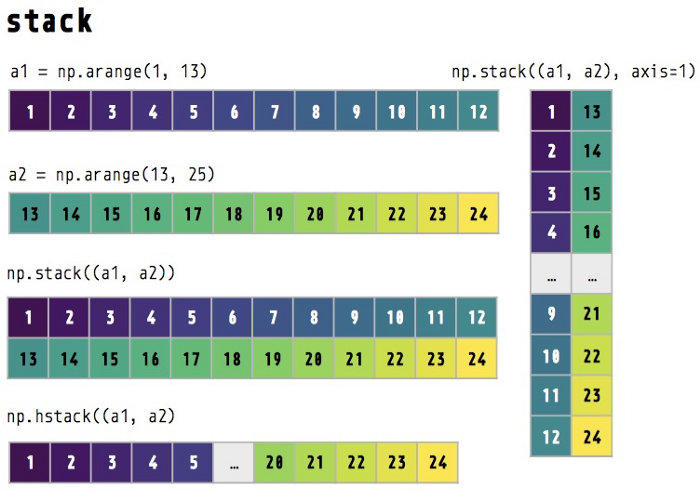

In [ ]:
a1 = np.arange(1, 13)
a2 = np.arange(13, 25)
stack0 = np.stack((a1, a2))            # empile sur un nouvel axe 0 -> (2, 12)
print("stack axis=0 shape:", stack0.shape)
print(stack0)
stack1 = np.stack((a1, a2), axis=1)    # nouvel axe 1 -> (12, 2)
print("stack axis=1 shape:", stack1.shape)
stack_long = np.hstack((a1, a2))       # concatène bout-à-bout -> (24,)
print("hstack shape:", stack_long.shape)
print(np.vstack((a1, a2)).shape)       # empile en lignes -> (2, 12)
print(np.concatenate((a1, a2)).shape)  # concatène sur axe existant -> (24,)

En partant de deux matrices 2-D de même forme…

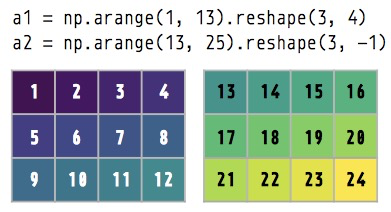

…`stack` selon l'axe choisi produit un tableau **3-D** : l'axe d'empilement détermine
où s'insère la nouvelle dimension (`axis=0` → `(2,3,4)`, `axis=1` → `(3,2,4)`, `axis=2` → `(3,4,2)`).

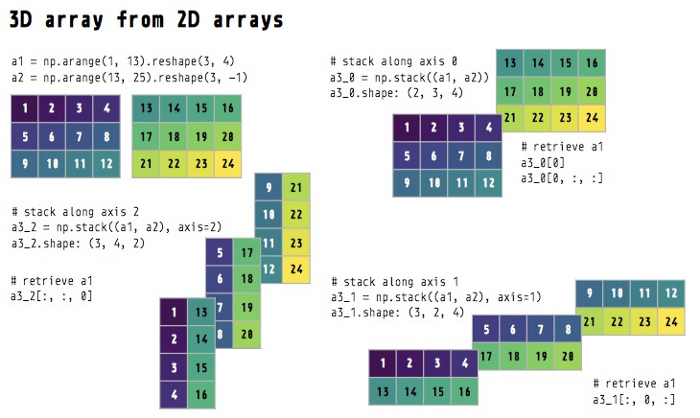

In [ ]:
A = np.arange(1, 13).reshape(3, 4)
B = np.arange(13, 25).reshape(3, -1)   # -1 -> 4 déduit
s0 = np.stack((A, B), axis=0)          # (2, 3, 4)
s1 = np.stack((A, B), axis=1)          # (3, 2, 4)
s2 = np.stack((A, B), axis=2)          # (3, 4, 2)
print("axis0:", s0.shape, "| axis1:", s1.shape, "| axis2:", s2.shape)
print("s0[0] =\n", s0[0])              # récupère la 1re matrice

**Indexing avancé** — au-delà du slicing : masque booléen (`arr[arr > 10]`),
*fancy indexing* (listes d'indices), filtrage de lignes par condition, et le ternaire
vectorisé `np.where(cond, si_vrai, si_faux)`.

In [ ]:
arr = np.arange(24).reshape(4, 6)
print(arr[1:3, 2:5])              # sous-bloc (lignes 1-2, cols 2-4)
print(arr[:, ::2])                # une colonne sur deux
print(arr[arr > 10])              # masque booléen -> 1D
print(arr[[0, 2], [1, 3]])        # fancy indexing -> [arr[0,1], arr[2,3]]
print(arr[arr.sum(axis=1) > 50])  # filtre de lignes par condition
print(np.where(arr > 10, arr, -1))  # ternaire vectorisé

**Broadcasting** — NumPy aligne les formes de droite à gauche : deux dimensions sont
compatibles si elles sont **égales** ou si l'une vaut **1** (elle est alors « étirée »).
Ainsi $(3,4) + (4,) \rightarrow (3,4)$ et $(3,4) + (3,1) \rightarrow (3,4)$, sans copie réelle.

In [ ]:
m = np.arange(12).reshape(3, 4)        # (3, 4)
v = np.array([10, 20, 30, 40])         # (4,)  -> broadcast en (1, 4)
print(m + v)                            # (3, 4)
col = np.array([[100], [200], [300]])  # (3, 1)
print(m + col)                          # (3, 4)

Les **ufuncs** (`np.sqrt`, `np.exp`, …) s'appliquent élément par élément. Les agrégations
prennent un `axis` : `axis=0` réduit les lignes (résultat par colonne), `axis=1` l'inverse.

In [ ]:
print(np.sqrt(arr.astype(float))[0])  # ufunc élément par élément
print(arr.sum(axis=0))                 # somme par colonne
print(arr.mean(axis=1))                # moyenne par ligne
print(arr.std())                       # écart-type global

Astuce : convertir une **liste de listes de longueurs inégales** en array rectangulaire en
*paddant* avec `None` jusqu'à la longueur max (le `dtype=object` est nécessaire ici).

In [ ]:
x = [[1, 2], [1, 2, 3], [1]]
length = max(map(len, x))              # longueur de la plus longue sous-liste
y = np.array([xi + [None] * (length - len(xi)) for xi in x], dtype=object)
print(y)

## 2. Listes

La `list` est la séquence mutable de référence. Slicing `start:stop:step` (négatif autorisé),
et un riche jeu de méthodes *in-place* (`append`, `extend`, `insert`, `remove`, `pop`, `sort`).

In [ ]:
xs = [3, 1, 4, 1, 5, 9, 2, 6]
print(xs[::-1])            # inversée
print(xs[1:6:2])           # start:stop:step
print(xs[:3] + xs[-3:])    # premiers + derniers (concat)
xs.append(0)               # ajoute 1 élément
xs.extend([7, 8])          # ajoute les éléments d'un itérable
xs.insert(0, -1)           # insère à l'index
xs.remove(1)               # supprime la 1re occurrence
print(xs.pop(0), xs.pop()) # retire+renvoie (index donné / dernier)
xs.sort()                  # tri in-place stable
print(sorted(xs, reverse=True))  # nouvelle liste triée décroissante

**Recherche et tri** : `index`/`count`, tri *in-place* `sort` vs `sorted` (nouvelle liste),
`reverse`, `join`, et tri personnalisé via `key` (`str.lower`, `lambda`).

In [ ]:
fruits = ["apple", "kiwi", "grape", "orange", "pear", "kiwi"]
print(fruits.index("orange"))   # 1re position
print(fruits.count("kiwi"))     # nb d'occurrences
numbers = [5, 2, 9, 1, 5]
numbers.sort(); print(numbers)  # tri in-place
numbers.reverse(); print(numbers)  # inverse l'ordre
print(", ".join(fruits))        # concatène une liste de str
msg = "Hello World!"
print(msg.replace("World", "Everyone"))
print(msg.rindex("o"))          # dernière position de "o"
words = ["apple", "Bee", "carrot"]
print(sorted(words, key=str.lower))                       # tri insensible à la casse
print(sorted([(1, "b"), (2, "a")], key=lambda t: t[1]))   # tri par 2e élément
numbers.clear(); print(numbers)  # vide la liste

**Aplatir** une liste de listes — par compréhension imbriquée ou via `itertools.chain` :

In [ ]:
nested = [[1, 2], [3, 4], [5, 6]]
print([x for sub in nested for x in sub])        # compréhension imbriquée
print(list(it.chain.from_iterable(nested)))      # via itertools

Conversion **liste de listes ↔ liste de tuples** (les tuples sont immuables et hashables) :

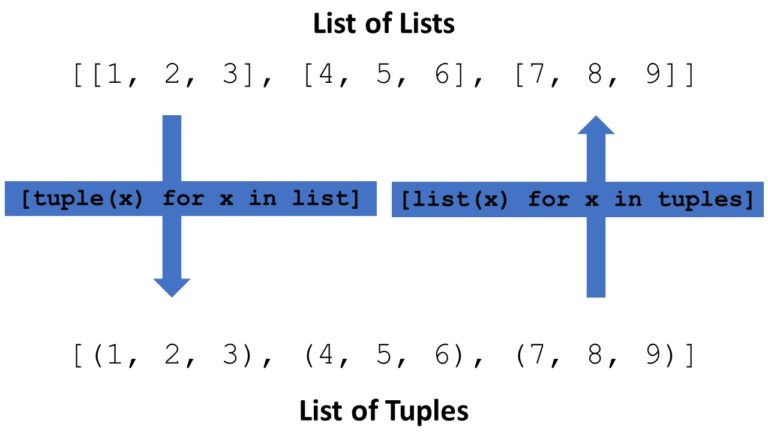

In [ ]:
lst = [[1, 2], [3, 4], [5, 6]]
tuples = [tuple(x) for x in lst]
print("tuples :", tuples)
back = [list(x) for x in tuples]
print("list   :", back)

**Découper une liste en `n` parts** aussi équilibrées que possible : les `len % n`
premières parts reçoivent un élément supplémentaire.

In [ ]:
def decouper_liste(liste: list[Any], n: int) -> list[list[Any]]:
    """Découpe `liste` en `n` sous-listes de tailles aussi égales que possible.

    Les `len(liste) % n` premières parties reçoivent un élément de plus.
    """
    taille = len(liste) // n
    reste = len(liste) % n
    parties, debut = [], 0
    for i in range(n):
        fin = debut + taille + (1 if i < reste else 0)
        parties.append(liste[debut:fin])
        debut = fin
    return parties


ma_liste = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1, 2, 3, 4]
for i, partie in enumerate(decouper_liste(ma_liste, 3), 1):
    print(f"Partie {i}: {partie}")

## 3. Chaînes de caractères (`str`)

Les `str` sont **immuables** : chaque méthode renvoie une **nouvelle** chaîne.
Casse : `capitalize` (1re lettre), `upper`/`lower`, `title` (chaque mot).

In [ ]:
ma_String = "Hello World!"
print(ma_String, "->", ma_String.capitalize())  # 1re lettre maj, reste min
print(ma_String, "->", ma_String.upper())        # tout en majuscules
print(ma_String, "->", ma_String.lower())        # tout en minuscules
print("hello world!", "->", "hello world!".title())  # chaque mot capitalisé

Nettoyage et alignement : `strip`/`lstrip`/`rstrip` rognent les espaces,
`ljust`/`rjust` complètent à largeur fixe, `encode` produit des `bytes`.

In [ ]:
s = "  Hello World! "
print(repr(s.strip()), repr(s.lstrip()), repr(s.rstrip()))  # rognage
base = "Hello World!"
print(base.ljust(15, "-"))   # aligné à gauche, complété par '-'
print(base.rjust(15, "-"))   # aligné à droite
print(base.encode("utf-8"))  # bytes

Recherche : `startswith`/`endswith` (acceptent un intervalle `start, end`),
`find` (renvoie `-1` si absent, contrairement à `index`/`rindex` qui lèvent), `replace`.

In [ ]:
message = "Hello World!"
print(message.startswith("Wo", 6, 12))  # préfixe dans l'intervalle [6,12)
print(message.endswith("!", -2, 20))    # suffixe sur la tranche
print(message.startswith("Hello"))      # sensible à la casse
print(message.find("World"), message.rindex("o"))  # find: -1 si absent ; rindex: depuis la fin

## 4. Tuples

Le `tuple` est une séquence **immuable** et **hashable** (donc utilisable comme clé de dict
ou élément de set). Unpacking avec `*` pour capturer le reste ; swap en une ligne.
`namedtuple` ajoute des champs nommés ; `dataclass(frozen=True)` est l'alternative moderne typée.

In [ ]:
t = (1, 2, 3)
a, b, c = t           # unpacking simple
first, *rest = t      # rest = [2, 3]
*init, last = t       # init = [1, 2], last = 3
x_, y_ = 10, 20
x_, y_ = y_, x_       # swap pythonique
print(first, rest, init, last, x_, y_)

Point = namedtuple("Point", ["x", "y"])
p = Point(3, 4)
print(p.x, p.y, p._asdict())


@dataclass(frozen=True)
class Vec2:
    """Vecteur 2D immuable (frozen) -> hashable, utilisable comme clé/élément de set."""
    x: float
    y: float


print(Vec2(1.0, 2.0))

Un `namedtuple` (hashable) fait une excellente **clé de dictionnaire** structurée :

In [ ]:
Name = namedtuple("Name", ["NOM", "PRENOM"])
dict_name = {
    Name(NOM="horellou", PRENOM="florian"): ("h", "f"),
    Name(NOM="suelves", PRENOM="thomas"): ("s", "t"),
}
print(dict_name[Name(NOM="horellou", PRENOM="florian")])

## 5. Dictionnaires

Le `dict` (table de hachage, ordre d'insertion garanti depuis 3.7) se construit aussi par
`dict(zip(clés, valeurs))`. Itération sur `.items()` / `.keys()` / `.values()`.

In [ ]:
list_1 = [(1, 2), (1, 2, 3), 1]
list_2 = ["[1,2]", "[1,2,3]", "[1]"]
d_zip = dict(zip(list_1, list_2))  # construit un dict à partir de 2 listes
print(d_zip)

roues = {"voiture": 4, "vélo": 2, "tricycle": 3}
print(list(roues.items()))   # paires (clé, valeur)
print(list(roues.keys()))    # clés
print(list(roues.values()))  # valeurs

Accès **sûr** : `get(clé, défaut)` et `setdefault`. Fusion : l'opérateur `|` (3.9+, la droite
gagne) ou une fonction `deepcopy`-based qui ne mute pas les entrées.

In [ ]:
d = {"a": 1, "b": 2, "c": 3}
print(d.get("z", 0))         # 0 si absent (pas de KeyError)
print(d.setdefault("z", 100))  # crée si absent et renvoie
d1, d2 = {"a": 1, "b": 2}, {"b": 20, "c": 30}
print(d1 | d2)               # merge moderne (3.9+), la droite gagne


def merge_dicts(dict1: dict, dict2: dict) -> dict:
    """Fusionne 2 dicts sans muter les entrées (copie profonde) ; dict2 prioritaire."""
    import copy
    new = copy.deepcopy(dict1)
    new.update(dict2)
    return new


print(merge_dicts({"x": 10, "y": 20}, {"y": 30, "z": 40}))

Transformations par compréhension : inverser clé↔valeur, filtrer, transformer les valeurs.
Les **dicts de dicts** modélisent des structures arborescentes.

In [ ]:
d = {"a": 1, "b": 2, "c": 3}
print({v: k for k, v in d.items()})         # inverser clé/valeur
print({k: v for k, v in d.items() if v > 1})  # filtrer
print({k: v * 2 for k, v in d.items()})     # transformer les valeurs

nested = {"users": {"alice": {"age": 30}, "bob": {"age": 25}}}
print(nested["users"]["alice"]["age"])

fruits = ["banana", "apple", "orange"]
my_dicts = {f: {} for f in fruits}          # dict de dicts via compréhension
print(my_dicts)

**Sous-dictionnaire** filtré sur les clés ou les valeurs :

In [ ]:
def subset_dict(my_dict: dict, keys: Iterable, on: str = "keys") -> dict:
    """Sous-dictionnaire filtré sur les clés (`on='keys'`) ou les valeurs (`on='values'`)."""
    keyset = set(keys)
    if on == "keys":
        return {k: v for k, v in my_dict.items() if k in keyset}
    return {k: v for k, v in my_dict.items() if v in keyset}


src = {"key1": 1, "key2": 2, "key3": 3, "key4": 4}
print(subset_dict(src, ["key1", "key3", "key99"], on="keys"))

Cas avancés : un **générateur** `flatten_obj` (mot-clé `yield`) aplatit récursivement tout
itérable imbriqué ; `deepflatten` (lib `iteration_utilities`) sert à filtrer/fusionner des dicts
dont les valeurs sont elles-mêmes des structures imbriquées.

In [ ]:
def flatten_obj(items: Iterable) -> Iterator:
    """Aplatit récursivement tout itérable imbriqué (sauf str/bytes).

    `yield` produit un générateur paresseux : les éléments sont émis à la demande.
    """
    for x in items:
        if isinstance(x, Iterable) and not isinstance(x, (str, bytes)):
            yield from flatten_obj(x)
        else:
            yield x


print(list(flatten_obj([1, [2, [3, 4], "ab"], 5])))

from iteration_utilities import deepflatten


def subset_dict_multi(my_dict: dict, wanted: Iterable, on: str = "keys") -> dict:
    """Garde les entrées dont la clé/valeur (aplatie) intersecte `wanted`."""
    wanted = set(wanted)
    out = {}
    for k, v in my_dict.items():
        obj = k if on == "keys" else v
        flat = list(deepflatten(obj)) if isinstance(obj, Iterable) and not isinstance(obj, str) else [obj]
        if wanted & set(flat):
            out[k] = v
    return out


dict_test = {("a", "b"): [1, 2], ("c", "c"): [3, 4], "b": [5, 6]}
print(subset_dict_multi(dict_test, ["a", "b"], on="keys"))


def merge_dicts_accumulate(dict1: dict, dict2: dict, flat: bool = False) -> dict:
    """Fusionne en accumulant les valeurs des clés communes dans une liste.

    Si `flat=True`, aplatit les valeurs accumulées (deepflatten).
    """
    out: dict = {}
    for key in set(dict1) | set(dict2):
        for src in (dict1, dict2):
            if key in src:
                out.setdefault(key, []).append(src[key])
    if flat:
        out = {k: list(deepflatten(v)) for k, v in out.items()}
    return out


A = {"x": [10, 2], "y": 20}
B = {"x": 30, "z": 40}
print("flat   :", merge_dicts_accumulate(A, B, flat=True))
print("no flat:", merge_dicts_accumulate(A, B, flat=False))

## 6. Sets

Le `set` est une collection **non ordonnée** d'éléments **uniques** et hashables, optimisée
pour l'appartenance (`in` en O(1) moyen) et l'algèbre ensembliste. `frozenset` en est la version
immuable (hashable).

In [ ]:
sa, sb = {1, 2, 3, 4}, {3, 4, 5, 6}
print(sa | sb)   # union
print(sa & sb)   # intersection
print(sa - sb)   # différence
print(sa ^ sb)   # différence symétrique
print(sa.issubset(sb), sa.isdisjoint(sb))
fs = frozenset({1, 2, 3})  # set immuable -> hashable
print(fs)

## 7. Le module `collections`

La stdlib `collections` fournit des conteneurs spécialisés : `Counter` (comptage),
`defaultdict` (valeur par défaut), `deque` (file double extrémité O(1), `maxlen` borné),
`OrderedDict` (ordre + `move_to_end`), `ChainMap` (vue sur plusieurs dicts).

In [ ]:
c = Counter("mississippi")
print(c.most_common(3))                # [('i',4), ('s',4), ('p',2)]

by_len = defaultdict(list)             # valeur par défaut auto à la création
for w in ["apple", "bee", "car", "dog"]:
    by_len[len(w)].append(w)
print(dict(by_len))

dq = deque([1, 2, 3], maxlen=5)        # file double extrémité, taille bornée
dq.appendleft(0); dq.extend([4, 5, 6])  # éjecte à gauche quand > maxlen
print(dq)

od = OrderedDict([("a", 1), ("b", 2)])  # garde l'ordre (utile pour move_to_end)
od.move_to_end("a")
print(od)

cm = ChainMap({"a": 1}, {"a": 2, "b": 3})  # vue multi-dicts, 1er gagnant
print(dict(cm))

## 8. xarray — tableaux N-D labellisés

**xarray** = NumPy + pandas pour les tableaux multi-dimensionnels : des dimensions **nommées**,
des **coordonnées** et des **métadonnées**. On sélectionne **par label** (`.sel`) plutôt que par
position, ce qui rend le code lisible et robuste. Standard des données géo/climat/neuro et des
tenseurs ML à axes interprétables.

In [ ]:
import pandas as pd
import xarray as xr

da = xr.DataArray(
    rng.standard_normal((3, 4, 5)),
    dims=["time", "lat", "lon"],
    coords={
        "time": pd.date_range("2026-01-01", periods=3),
        "lat": [-90, -45, 0, 45],
        "lon": [0, 90, 180, 270, 360],
    },
    name="temperature",
)
print(da.sel(time="2026-01-01", lat=0).values)  # sélection PAR LABEL
print(da.sel(lat=slice(-45, 45)).shape)          # slice de labels
print(da.mean(dim="time").shape)                 # agrège la dim time (conserve lat/lon)

On crée aussi un `Dataset` directement depuis un `DataFrame` (`.to_xarray()`). `groupby` agrège
par valeur d'une variable, et `to_netcdf` / `open_dataset` sérialisent au format **NetCDF**
(standard d'échange scientifique auto-descriptif).

In [ ]:
from pathlib import Path

import seaborn as sns

iris = sns.load_dataset("iris")
ds = iris.to_xarray()                 # Dataset avec dim "index"
print(ds)
print("moyenne sepal_length:", float(ds["sepal_length"].mean()))
print(ds.groupby("species").mean())   # moyenne par espèce (groupby sur une variable)

data_dir = Path("data/Structures_L_T_D_Cheat_Sheet")
data_dir.mkdir(parents=True, exist_ok=True)
nc_path = data_dir / "iris_dataset.nc"
ds.to_netcdf(nc_path)                 # sérialisation NetCDF
loaded = xr.open_dataset(nc_path)     # relecture
print("rechargé:", list(loaded.data_vars))
loaded.close()

print("\n[OK] notebook_Structures_L_T_D_Cheat_Sheet end-to-end")

## 9. Sources & notebooks liés

- [NumPy — User Guide](https://numpy.org/doc/stable/user/)
- [Python `collections`](https://docs.python.org/3/library/collections.html)
- [xarray — documentation](https://docs.xarray.dev/)
- [`iteration_utilities`](https://iteration-utilities.readthedocs.io/)
- Notebooks liés : `Structure_Python`, `Structures_DataFrame`, `Structures_Preprocessing`.